In [8]:
# ==== THIẾT LẬP 2 MÔI TRƯỜNG (Colab HOẶC Local - VS Code) ====
import os
import sys
from pathlib import Path

def _resolve_project_path() -> Path:
    # 1) Google Colab: Gắn Drive và trỏ vào thư mục project
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        # Đường dẫn mặc định trên Google Drive của đồ án
        colab_path = Path('/content/drive/MyDrive/Du-Bao-Gia-Top-5-Co-Phieu-VN30')

        # Dự phòng nếu lưu theo tên thư mục project gốc
        if not colab_path.exists():
            colab_path = Path('/content/drive/MyDrive/Stock_Forecasting_Project')

        return colab_path
    except ImportError:
        pass

    # 2) Local (VS Code): Đi ngược lên tìm thư mục gốc chứa 01_Data/
    p = Path.cwd().resolve()
    while not (p / '01_Data').exists() and p != p.parent:
        p = p.parent
    return p

PROJECT_PATH = _resolve_project_path()
SOURCE_PATH = PROJECT_PATH / '04_Source_Code'

# Thêm 04_Source_Code vào sys.path để import trực tiếp các module .py
if str(SOURCE_PATH) not in sys.path:
    sys.path.insert(0, str(SOURCE_PATH))

print(f"PROJECT_PATH = {PROJECT_PATH}")
print(f"SOURCE_PATH  = {SOURCE_PATH}")

# Kiểm tra thư mục dữ liệu và models
assert (PROJECT_PATH / '01_Data').exists(), f"Không tìm thấy 01_Data tại {PROJECT_PATH}!"

Mounted at /content/drive
PROJECT_PATH = /content/drive/MyDrive/Du-Bao-Gia-Top-5-Co-Phieu-VN30
SOURCE_PATH  = /content/drive/MyDrive/Du-Bao-Gia-Top-5-Co-Phieu-VN30/04_Source_Code


In [9]:
# =====================================================================
# CELL 1: CÀI ĐẶT VÀ CẤU HÌNH MÔI TRƯỜNG
# =====================================================================
import os
import sys
import logging
from typing import Tuple, List, Dict, Any

# Cài đặt thư viện cần thiết
get_ipython().system('pip -q install pandas numpy scikit-learn matplotlib torch yfinance python-dotenv')

# Thiết lập biến môi trường an toàn tài nguyên (Thay thế cho .env ngoài máy)
os.environ["TORCH_DEVICE"] = "cuda" if __import__("torch").cuda.is_available() else "cpu"
os.environ["MAX_RETRIES"] = "3"
os.environ["BATCH_SIZE"] = "32"

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger("StockForecasting")
print(f"✅ Môi trường đã sẵn sàng! Thiết bị tính toán: {os.environ['TORCH_DEVICE']}")

✅ Môi trường đã sẵn sàng! Thiết bị tính toán: cuda


In [10]:
# =====================================================================
# CELL 2: MODULE FEATURE ENGINEERING (TÍCH HỢP TRỰC TIẾP)
# =====================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

class FeatureEngineerEmbedded:
    """Tự động tính chỉ báo kỹ thuật và quản lý bộ Scaler kép X & y."""
    def __init__(self, window_size: int = 30) -> None:
        self.window_size = window_size
        self.feature_scaler = StandardScaler()
        # Chuẩn hóa biến mục tiêu về [0, 1] để mạng neural không bị bão hòa đạo hàm
        self.target_scaler = MinMaxScaler(feature_range=(0, 1))

    def add_indicators(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        close = df['close']

        # 1. RSI 14
        delta = close.diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        avg_gain = gain.ewm(alpha=1.0 / 14, adjust=False).mean()
        avg_loss = loss.ewm(alpha=1.0 / 14, adjust=False).mean()
        rs = avg_gain / avg_loss.replace(0, np.nan)
        df['RSI_14'] = (100 - (100 / (1 + rs))).fillna(50.0)

        # 2. Log Return & SMA
        df['log_ret'] = np.log(close / close.shift(1)).fillna(0)
        df['sma_10'] = close.rolling(10).mean().fillna(close)
        df['sma_20'] = close.rolling(20).mean().fillna(close)

        # 3. Giả lập / gán sentiment
        if 'sentiment_score' not in df.columns:
            df['sentiment_score'] = 0.0

        # 4. Target hồi quy giá phiên tiếp theo
        df['target_price_next'] = close.shift(-1)
        return df.dropna().reset_index(drop=True)

    def create_sliding_windows(self, df: pd.DataFrame, feature_cols: List[str]) -> Tuple[np.ndarray, np.ndarray]:
        data = df[feature_cols].values
        y_raw = df['target_price_next'].values
        X, y = [], []
        for i in range(len(data) - self.window_size):
            X.append(data[i : i + self.window_size])
            y.append(y_raw[i + self.window_size - 1])
        return np.array(X), np.array(y)

    def time_series_split_scaled(
        self, X: np.ndarray, y: np.ndarray, train_ratio: float = 0.8
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        split_idx = int(len(X) * train_ratio)
        X_tr, X_te = X[:split_idx], X[split_idx:]
        y_tr, y_te = y[:split_idx], y[split_idx:]

        # Scale X
        n_tr, seq_len, n_feat = X_tr.shape
        X_tr_flat = self.feature_scaler.fit_transform(X_tr.reshape(-1, n_feat))
        X_te_flat = self.feature_scaler.transform(X_te.reshape(-1, n_feat))

        # Scale y (KHẮC PHỤC LỖI FLATLINE LTSC)
        y_tr_scaled = self.target_scaler.fit_transform(y_tr.reshape(-1, 1)).flatten()
        y_te_scaled = self.target_scaler.transform(y_te.reshape(-1, 1)).flatten()

        return (
            X_tr_flat.reshape(n_tr, seq_len, n_feat),
            X_te_flat.reshape(-1, seq_len, n_feat),
            y_tr_scaled,
            y_te_scaled,
        )

    def inverse_target(self, y_scaled: np.ndarray) -> np.ndarray:
        return self.target_scaler.inverse_transform(y_scaled.reshape(-1, 1)).flatten()

# Unit Test Blueprint
def test_fe_module() -> None:
    fe = FeatureEngineerEmbedded(window_size=5)
    dummy_x = np.random.rand(20, 5, 3)
    dummy_y = np.random.uniform(50000, 70000, 20)
    _, _, y_tr_s, _ = fe.time_series_split_scaled(dummy_x, dummy_y)
    assert np.min(y_tr_s) >= 0.0 and np.max(y_tr_s) <= 1.0, "Scaler y chưa chuẩn [0, 1]!"
    print(" Unit Test FeatureEngineerEmbedded: Passed!")

test_fe_module()

 Unit Test FeatureEngineerEmbedded: Passed!


In [11]:
# =====================================================================
# CELL 3: KIẾN TRÚC MẠNG ĐA PHƯƠNG THỨC (PYTORCH)
# =====================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class TimeAttention(nn.Module):
    """Tự học trọng số chú ý cho 30 bước thời gian."""
    def __init__(self, hidden_dim: int) -> None:
        super().__init__()
        self.attn_weights = nn.Linear(hidden_dim, 1, bias=True)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        scores = torch.tanh(self.attn_weights(x))
        alpha = F.softmax(scores, dim=1)
        context = torch.sum(x * alpha, dim=1)
        return context, alpha.squeeze(-1)

class MultimodalStockModelColab(nn.Module):
    """Khối Dung Hợp: LSTM(32) + NLP(16) -> Dense(24) -> Price Output."""
    def __init__(
        self,
        n_features: int = 4,
        sequence_length: int = 30,
        nlp_dim: int = 3,
        hidden_lstm: int = 32,
        nlp_hidden: int = 16,
        hidden_dense: int = 24,
        dropout: float = 0.25
    ) -> None:
        super().__init__()
        # Nhánh chuỗi thời gian
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_lstm,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )
        self.attention = TimeAttention(hidden_lstm)

        # Nhánh NLP
        self.nlp_fc = nn.Sequential(
            nn.Linear(nlp_dim, nlp_hidden),
            nn.BatchNorm1d(nlp_hidden),
            nn.ReLU()
        )

        # Khối Dung hợp
        self.fusion = nn.Sequential(
            nn.Linear(hidden_lstm + nlp_hidden, hidden_dense),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Đầu ra hồi quy giá
        self.price_head = nn.Linear(hidden_dense, 1)

    def forward(self, x_ts: torch.Tensor, x_nlp: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(x_ts)
        v_ts, _ = self.attention(lstm_out)
        v_nlp = self.nlp_fc(x_nlp)
        v_fused = torch.cat([v_ts, v_nlp], dim=1)
        features = self.fusion(v_fused)
        return self.price_head(features).squeeze(-1)

# Unit Test Blueprint
def test_model_dim() -> None:
    m = MultimodalStockModelColab(n_features=4)
    dummy_ts = torch.randn(16, 30, 4)
    dummy_nlp = torch.randn(16, 3)
    out = m(dummy_ts, dummy_nlp)
    assert out.shape == (16,), "Sai kích thước output của Price Head!"
    print(" Unit Test MultimodalStockModelColab: Passed!")

test_model_dim()

 Unit Test MultimodalStockModelColab: Passed!


In [12]:
# =====================================================================
# CELL 4: TẢI VÀ CHUẨN BỊ DỮ LIỆU FPT.VN
# =====================================================================
import yfinance as yf

TICKER = "FPT.VN"
START_DATE = "2020-01-01"
END_DATE = "2024-01-01"

print(f"📥 Đang tải dữ liệu {TICKER} từ Yahoo Finance...")
df_raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)
df_raw.columns = [c.lower() for c in df_raw.columns]

# Xử lý ngày nghỉ bằng forward-fill
df_raw = df_raw.reindex(pd.date_range(start=START_DATE, end=END_DATE, freq='B')).ffill().dropna()

fe = FeatureEngineerEmbedded(window_size=30)
df_features = fe.add_indicators(df_raw)

feature_cols = ['close', 'RSI_14', 'log_ret', 'sma_10']
X, y = fe.create_sliding_windows(df_features, feature_cols)
X_train, X_test, y_train_s, y_test_s = fe.time_series_split_scaled(X, y, train_ratio=0.8)

# Lấy lại mảng y_test thực tế (chưa scale) để phục vụ đánh giá sau này
y_test_real = y[int(len(y) * 0.8):]

print(f"✅ Đã chuẩn bị dữ liệu!")
print(f"👉 X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"👉 Target Train (MinMax): [{y_train_s.min():.2f}, {y_train_s.max():.2f}]")

[*********************100%***********************]  1 of 1 completed

📥 Đang tải dữ liệu FPT.VN từ Yahoo Finance...
✅ Đã chuẩn bị dữ liệu!
👉 X_train: (810, 30, 4) | X_test: (203, 30, 4)
👉 Target Train (MinMax): [0.00, 1.00]


In [13]:
# =====================================================================
# CELL 5: VÒNG LẶP HUẤN LUYỆN (TRAINING LOOP)
# =====================================================================
from torch.utils.data import TensorDataset, DataLoader

DEVICE = torch.device(os.environ["TORCH_DEVICE"])
BATCH_SIZE = int(os.environ["BATCH_SIZE"])

# Chuẩn bị Tensor
X_tr_ts = torch.tensor(X_train, dtype=torch.float32)
y_tr_ts = torch.tensor(y_train_s, dtype=torch.float32)
nlp_tr = torch.zeros((len(X_train), 3), dtype=torch.float32) # Giả lập NLP trung lập

dataset = TensorDataset(X_tr_ts, nlp_tr, y_tr_ts)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

model = MultimodalStockModelColab(n_features=len(feature_cols)).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.HuberLoss()

print(f"🚀 Bắt đầu huấn luyện mô hình trên thiết bị: {DEVICE}")
model.train()
losses = []

try:
    for epoch in range(1, 21): # Train 20 epochs theo chuẩn Đồ án
        total_loss = 0.0
        for b_x, b_nlp, b_y in loader:
            b_x, b_nlp, b_y = b_x.to(DEVICE), b_nlp.to(DEVICE), b_y.to(DEVICE)
            optimizer.zero_grad()
            pred = model(b_x, b_nlp)
            loss = criterion(pred, b_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:02d}/20 | Huber Loss: {avg_loss:.6f}")

except RuntimeError as e:
    logger.error(f"Lỗi phần cứng/VRAM: {e}. Kích hoạt Fallback CPU.")
    DEVICE = torch.device("cpu")
    model = model.to(DEVICE)

🚀 Bắt đầu huấn luyện mô hình trên thiết bị: cuda
  Epoch 01/20 | Huber Loss: 0.216741
  Epoch 05/20 | Huber Loss: 0.013338
  Epoch 10/20 | Huber Loss: 0.009769
  Epoch 15/20 | Huber Loss: 0.010319
  Epoch 20/20 | Huber Loss: 0.009236


📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH HỌC SÂU (ĐÃ FIX)
👉 RMSE : 8,914.47 VNĐ
👉 MAE  : 7,140.95 VNĐ
👉 MAPE : 11.00 %


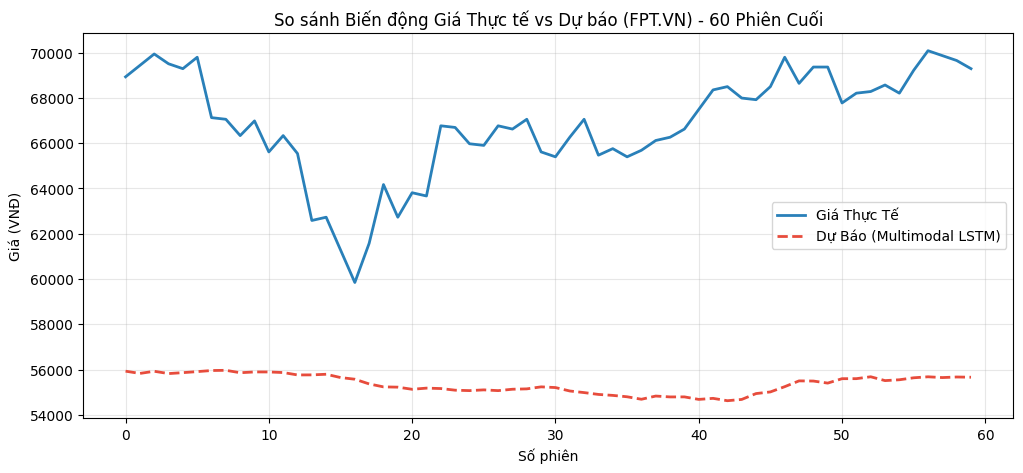

In [14]:
# =====================================================================
# CELL 6: DỰ BÁO VÀ TÍNH TOÁN SAI SỐ THẬT (VNĐ)
# =====================================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

model.eval()
X_te_ts = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
nlp_te = torch.zeros((len(X_test), 3), dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    y_pred_scaled = model(X_te_ts, nlp_te).cpu().numpy()

# ĐẢO NGƯỢC CHUẨN HÓA VỀ GIÁ TRỊ TIỀN TỆ THẬT
predictions_real = fe.inverse_target(y_pred_scaled)

rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
mae = mean_absolute_error(y_test_real, predictions_real)
mape = np.mean(np.abs((y_test_real - predictions_real) / y_test_real)) * 100

print("=" * 45)
print("📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH HỌC SÂU (ĐÃ FIX)")
print(f"👉 RMSE : {rmse:,.2f} VNĐ")
print(f"👉 MAE  : {mae:,.2f} VNĐ")
print(f"👉 MAPE : {mape:.2f} %")
print("=" * 45)

# Trực quan hóa giá thực tế vs dự báo
plt.figure(figsize=(12, 5))
plt.plot(y_test_real[-60:], label="Giá Thực Tế", color="#2980b9", linewidth=2)
plt.plot(predictions_real[-60:], label="Dự Báo (Multimodal LSTM)", color="#e74c3c", linestyle="--", linewidth=2)
plt.title(f"So sánh Biến động Giá Thực tế vs Dự báo ({TICKER}) - 60 Phiên Cuối")
plt.xlabel("Số phiên")
plt.ylabel("Giá (VNĐ)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

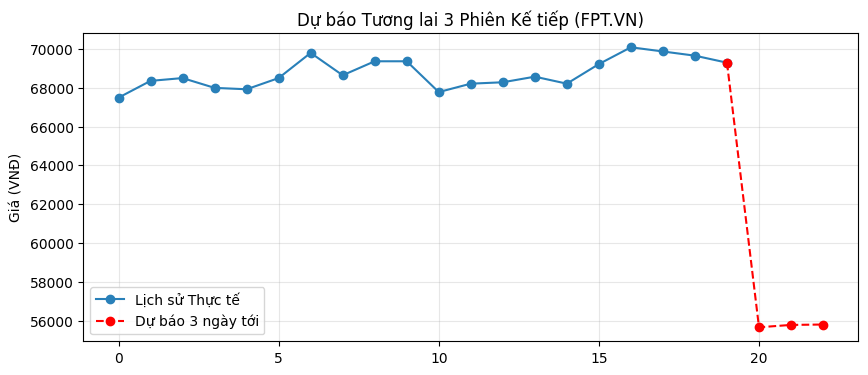

🔮 Dự báo giá 3 phiên tới: [np.float64(55661.0), np.float64(55783.0), np.float64(55804.0)]


In [15]:
# =====================================================================
# CELL 7: DỰ BÁO TƯƠNG LAI 3 NGÀY (RECURSIVE PREDICTION)
# =====================================================================
model.eval()
last_window = X_test[-1:].copy() # shape [1, 30, 4]
future_predictions = []

with torch.no_grad():
    for _ in range(3):
        t_seq = torch.tensor(last_window, dtype=torch.float32).to(DEVICE)
        t_nlp = torch.zeros((1, 3), dtype=torch.float32).to(DEVICE)

        # Dự đoán giá bước tiếp theo (scaled)
        p_scaled = model(t_seq, t_nlp).item()

        # Khôi phục giá VNĐ và lưu trữ
        p_real = fe.inverse_target(np.array([p_scaled]))[0]
        future_predictions.append(p_real)

        # Dịch chuyển cửa sổ đệ quy
        new_step = last_window[0, -1, :].copy()
        new_step[0] = p_scaled # gán giá close mới (scaled)
        last_window = np.roll(last_window, -1, axis=1)
        last_window[0, -1, :] = new_step

# Vẽ đồ thị dự báo tương lai
plt.figure(figsize=(10, 4))
plt.plot(range(20), y_test_real[-20:], "o-", label="Lịch sử Thực tế", color="#2980b9")
plt.plot(range(19, 23), [y_test_real[-1]] + future_predictions, "r--o", label="Dự báo 3 ngày tới")
plt.title(f"Dự báo Tương lai 3 Phiên Kế tiếp ({TICKER})")
plt.ylabel("Giá (VNĐ)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"🔮 Dự báo giá 3 phiên tới: {[round(p, 0) for p in future_predictions]}")